In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 06 NASA CMAPSS RUL Prediction

## Problem Statement

Remaining Useful Life (RUL) is the number of operational
cycles/ trajectories remaining before a machine requires maintenance
or fails completely.

For jet engines — getting this wrong isn't an inconvenience.
It's a catastrophe.

This notebook uses NASA's CMAPSS turbofan degradation dataset
to predict RUL from sensor readings alone.
No manual inspection. No human judgment.
Just data, physics, and a model that learns degradation.

## Physics Context

As cycles accumulate, engine components degrade —
compressor blades wear, turbine coatings thin,
small gaps form in tight tolerances.

This degradation shows up in sensor readings —
temperatures rise, pressures drift, efficiency drops.
The signal is subtle at first, then accelerates near failure.

RUL = total cycles until failure − current cycle

At RUL = 0, the engine requires immediate maintenance.
The goal — predict RUL before it reaches zero.

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
# Importing the complete folder
import os

path = 'drive/MyDrive/ml_as_beginner/projects/hence_proved/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData'
print(os.listdir(path))

readme_path = path + '/readme.txt'
training_data_path = path + '/train_FD001.txt'

def print_file_content(file_path):
  with open(file_path, encoding='latin_1') as f:
    return f.read()

# print(print_file_content(training_data_path))




['train_FD001.txt', 'test_FD001.txt', 'train_FD003.txt', 'test_FD003.txt', 'train_FD002.txt', 'test_FD002.txt', 'train_FD004.txt', 'test_FD004.txt', 'RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD004.txt', 'RUL_FD003.txt', 'readme.txt', 'Damage Propagation Modeling.pdf']


In [5]:
# CONFIG
DATA_PATH = "drive/MyDrive/ml_as_beginner/projects/hence_proved/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData"
DATASET = "FD001"
MAX_RUL = 125
TEST_SIZE = 0.2
RANDOM_SEED = 42

# COLUMN NAME
COLUMNS = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [ f's{i}' for i in range(1, 22)]

In [6]:
def load_data(path, dataset):
    train = pd.read_csv(
        f'{path}/train_{dataset}.txt',
        sep=r'\s+',           # ← handles variable whitespace
        header=None,
        names=COLUMNS,
        engine='python'
    ).dropna(axis=1)

    test = pd.read_csv(
        f'{path}/test_{dataset}.txt',
        sep=r'\s+',
        header=None,
        names=COLUMNS,
        engine='python'
    ).dropna(axis=1)

    rul = pd.read_csv(
        f'{path}/RUL_{dataset}.txt',
        header=None,
        names=['RUL']
    )

    return train, test, rul

train, test, rul_test = load_data(DATA_PATH, DATASET)

# print(train.head(3))

print("Unique engines in train:", train['unit'].nunique())
print("Unique engines in test:", test['unit'].nunique())
print("\nFirst engine life:")
print(train[train['unit']==1]['cycle'].max(), "cycles")
print("\nLast engine life:")
print(train[train['unit']==100]['cycle'].max(), "cycles")

Unique engines in train: 100
Unique engines in test: 100

First engine life:
192 cycles

Last engine life:
200 cycles


#### In real aerospace sensor data — some sensors monitor ambient conditions, not component health. They're useful for normalisation but not for degradation prediction.
Dropping them is standard practice in CMAPSS literature. Every research paper on this dataset does it.

In [7]:
# Check standard deviation of each sensor
print(train.std().sort_values())

os3      0.000000e+00
s18      0.000000e+00
s19      0.000000e+00
s16      1.556432e-14
s10      4.660829e-13
s5       3.394700e-12
s1       6.537152e-11
os2      2.930621e-04
s6       1.388985e-03
os1      2.187313e-03
s15      3.750504e-02
s8       7.098548e-02
s13      7.191892e-02
s21      1.082509e-01
s20      1.807464e-01
s11      2.670874e-01
s2       5.000533e-01
s12      7.375534e-01
s7       8.850923e-01
s17      1.548763e+00
s3       6.131150e+00
s4       9.000605e+00
s14      1.907618e+01
s9       2.208288e+01
unit     2.922763e+01
cycle    6.888099e+01
dtype: float64


In [8]:
# for column in train.columns.tolist():
#   print(f"Unique values in column : {column}  -> {train[column].nunique()}")

# print(train['os1'].describe())
# print(train['os2'].describe())

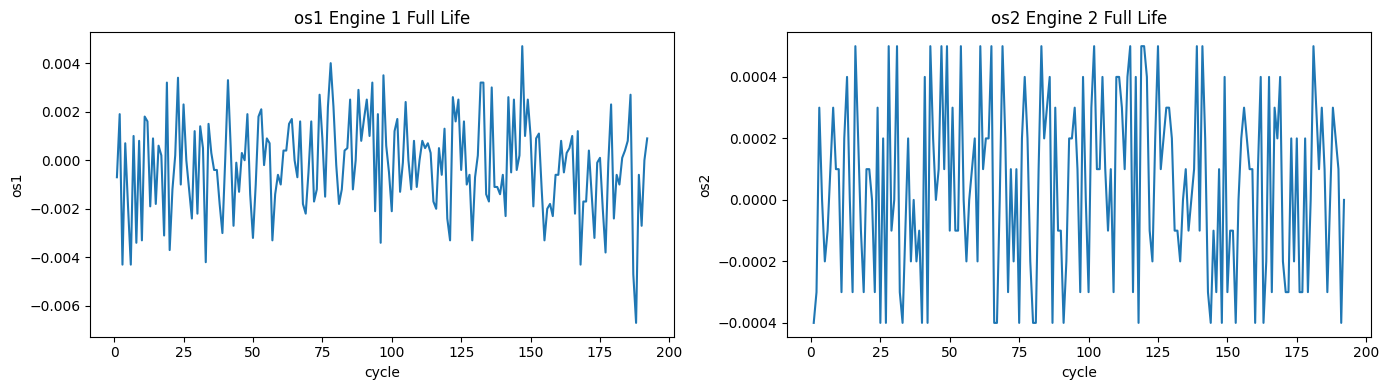

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))


sns.lineplot(data=train[train['unit']==1], x='cycle', y='os1', ax=axes[0])
axes[0].set_title('os1 Engine 1 Full Life')

sns.lineplot(data=train[train['unit']==1], x='cycle', y='os2', ax=axes[1])
axes[1].set_title('os2 Engine 2 Full Life')

plt.tight_layout()
plt.show()

#Confirmed that the data from os1, os2 are noise

In [10]:
DROP_COLUMNS = ['os1','os2','os3', 's1', 's5', 's6', 's10', 's16', 's18', 's19']

def drop_colums(df, columns_to_drop):
  return df.drop(columns=columns_to_drop)

train_clean = drop_colums(train, DROP_COLUMNS)
test_clean = drop_colums(test, DROP_COLUMNS)

print(train.columns.tolist())
print(f"Train shape before dropping columns : {train.shape}")
print(f"Train shape after dropping columns: {train_clean.shape}")


['unit', 'cycle', 'os1', 'os2', 'os3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']
Train shape before dropping columns : (20631, 26)
Train shape after dropping columns: (20631, 16)


In [11]:
max_cycles_per_engine = train.groupby('unit')['cycle'].max().reset_index()
max_cycles_per_engine.columns = ['unit', 'max_cycle']
print(max_cycles_per_engine)

    unit  max_cycle
0      1        192
1      2        287
2      3        179
3      4        189
4      5        269
..   ...        ...
95    96        336
96    97        202
97    98        156
98    99        185
99   100        200

[100 rows x 2 columns]


In [12]:
# Calculating RUL for the complete dataset

def add_rul(df):
    max_cycles = df.groupby('unit')['cycle'].max().reset_index()
    max_cycles.columns = ['unit', 'max_cycle']
    df = df.merge(max_cycles, on='unit')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df = df.drop('max_cycle', axis=1)
    return df

train_clean = add_rul(train_clean)

print(train_clean[['unit', 'cycle', 'RUL']].head(10))
print(f"\nMax RUL: {train_clean['RUL'].max()}")
print(f"Min RUL: {train_clean['RUL'].min()}")

   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182

Max RUL: 361
Min RUL: 0


Max RUL after cap :125
Min RUL after cap :0


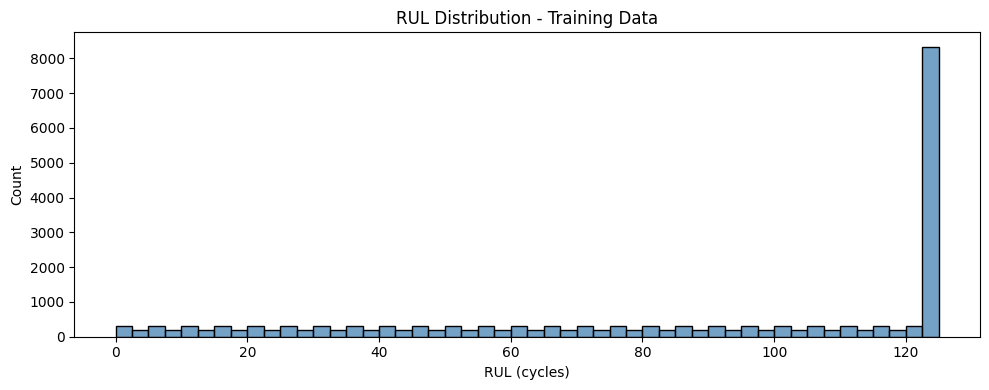

In [13]:
# Convention from the research community. The original NASA CMAPSS paper and most subsequent research papers use 125 as the cap.

train_clean['RUL'] = train_clean['RUL'].clip(upper=MAX_RUL)

print(f"Max RUL after cap :{train_clean['RUL'].max()}")
print(f"Min RUL after cap :{train_clean['RUL'].min()}")

plt.figure(figsize=(10,4))
sns.histplot(train_clean['RUL'], bins=50, color='steelblue', edgecolor='black')
plt.title('RUL Distribution - Training Data')
plt.xlabel("RUL (cycles)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [14]:
#Since the data is left skewed, need to Normalize the data

def normalize_per_engine(df, sensor_cols):

  df = df.copy()
  for unit in df['unit'].unique():
    mask = df['unit'] == unit
    scaler = MinMaxScaler()
    df.loc[mask, sensor_cols] = scaler.fit_transform(
        df.loc[mask, sensor_cols]
    )

  return df

SENSOR_COLS = [c for c in train_clean.columns if c.startswith('s')]

train_clean_norm = normalize_per_engine(train_clean, SENSOR_COLS)
test_clean_norm = normalize_per_engine(test_clean, SENSOR_COLS)

# print(f"Training cleaned normalized data : {train_clean_norm[SENSOR_COLS].describe().round(3)}")

/tmp/ipykernel_1127/2711813064.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.25  0.25  0.    0.25  0.375 0.125 0.25  0.125 0.25  0.375 0.25  0.125
 0.375 0.375 0.125 0.25  0.25  0.25  0.125 0.25  0.25  0.25  0.25  0.25
 0.375 0.5   0.375 0.    0.375 0.    0.25  0.25  0.25  0.25  0.125 0.25
 0.25  0.25  0.25  0.25  0.25  0.25  0.25  0.25  0.375 0.375 0.25  0.25
 0.25  0.25  0.375 0.125 0.25  0.25  0.25  0.125 0.25  0.    0.25  0.375
 0.125 0.125 0.5   0.125 0.25  0.125 0.375 0.25  0.25  0.25  0.125 0.125
 0.125 0.25  0.25  0.    0.375 0.25  0.5   0.25  0.25  0.375 0.125 0.25
 0.25  0.5   0.125 0.25  0.25  0.125 0.5   0.25  0.25  0.375 0.5   0.25
 0.25  0.125 0.375 0.25  0.125 0.375 0.25  0.25  0.375 0.25  0.75  0.375
 0.5   0.375 0.25  0.5   0.375 0.5   0.375 0.5   0.125 0.375 0.5   0.375
 0.5   0.375 0.25  0.375 0.5   0.25  0.375 0.375 0.375 0.5   0.125 0.375
 0.5   0.375 0.25  0.375 0.5   0.25 

In [15]:
# Feature Engineering

FEATURE_COLS = [c for c in train_clean_norm.columns if c not in ['unit', 'cycle', 'RUL']]

X = train_clean_norm[FEATURE_COLS]
y = train_clean_norm['RUL']

print(X.shape)
print(y.shape)

(20631, 14)
(20631,)


In [16]:
# Get last cycle for each test engine
test_last = test_clean_norm.groupby('unit').last().reset_index()

X_test_clean = test_last[FEATURE_COLS]
y_test_clean = rul_test['RUL']

## Model 01

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print("Model 01 Report")
print(f"Mean Absolute Error :{mean_absolute_error(y_test, y_pred_1)}")
print(f"Mean Squared Error :{np.sqrt(mean_squared_error(y_test, y_pred_1))}")
print(f"R2 score :{r2_score(y_test, y_pred_1)}")

Model 01 Report
Mean Absolute Error :13.326596993562303
Mean Squared Error :16.730182949457102
R2 score :0.8350173916089014


### Testing Model 01 on actual testing set from NASA

In [18]:
y_pred_2 = model_1.predict(X_test_clean)

print("Model 01 Report on test set of data")
print(f"Mean Absolute Error :{mean_absolute_error(y_test_clean, y_pred_2)}")
print(f"Mean Squared Error :{np.sqrt(mean_squared_error(y_test_clean, y_pred_2)):.4f}")
print(f"R2 score :{r2_score(y_test_clean, y_pred_2)}")

mse = mean_squared_error(y_test_clean, y_pred_2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_clean, y_pred_2)

print("Model 01 Report on NASA Test Set")
print(f"MAE  : {mae:.4f} cycles")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f} cycles")
print(f"R²   : {r2_score(y_test_clean, y_pred_2):.4f}")

Model 01 Report on test set of data
Mean Absolute Error :55.40744060628904
Mean Squared Error :60.8952
R2 score :-1.1473695000977204
Model 01 Report on NASA Test Set
MAE  : 55.4074 cycles
MSE  : 3708.2271
RMSE : 60.8952 cycles
R²   : -1.1474


## Model 02 - Random Forest

In [19]:
model_2 = RandomForestRegressor(n_estimators=100, random_state=42)
model_2.fit(X, y)

y_pred_3 = model_2.predict(X_test_clean)

print("Model 02 Report :")
print(f"Mean Absolute Error :{mean_absolute_error(y_test_clean, y_pred_3)}")
print(f"Root Mean Squared Error :{np.sqrt(mean_squared_error(y_test_clean, y_pred_3))}")
print(f"R2 score :{r2_score(y_test_clean, y_pred_3)}")

Model 02 Report :
Mean Absolute Error :49.50819999999999
Root Mean Squared Error :58.73266881387223
R2 score :-0.9975604330518066


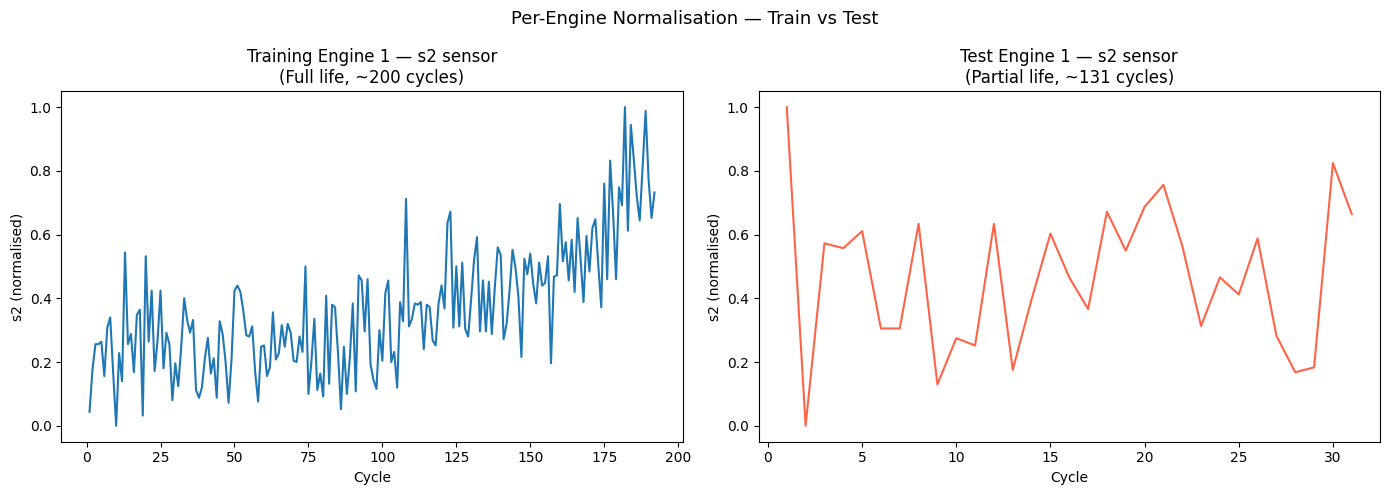

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training engine 1 — full life
train_eng1 = train_clean_norm[train_clean_norm['unit']==1]
axes[0].plot(train_eng1['cycle'], train_eng1['s2'])
axes[0].set_title("Training Engine 1 — s2 sensor\n(Full life, ~200 cycles)")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("s2 (normalised)")

# Test engine 1 — partial life
test_eng1 = test_clean_norm[test_clean_norm['unit']==1]
axes[1].plot(test_eng1['cycle'], test_eng1['s2'], color='tomato')
axes[1].set_title("Test Engine 1 — s2 sensor\n(Partial life, ~131 cycles)")
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("s2 (normalised)")

plt.suptitle("Per-Engine Normalisation — Train vs Test", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
print(test_clean_norm[test_clean_norm['unit']==1]['cycle'].max())

31


### The Normalisation

In [25]:
from sklearn.preprocessing import MinMaxScaler

# Fit on training data only
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)

# Transform test data using same scale
X_test_scaled = scaler.transform(X_test_clean)

# Retrain Random Forest
model_3 = RandomForestRegressor(n_estimators=100, random_state=42)
model_3.fit(X_train_scaled, y)

y_pred_3 = model_3.predict(X_test_scaled)

mse = mean_squared_error(y_test_clean, y_pred_3)
print("--- Model 3 --- RF + Global Normalisation ---")
print(f"MAE  : {mean_absolute_error(y_test_clean, y_pred_3):.4f}")
print(f"RMSE : {np.sqrt(mse):.4f}")
print(f"R²   : {r2_score(y_test_clean, y_pred_3):.4f}")

--- Model 3 --- RF + Global Normalisation ---
MAE  : 49.5082
RMSE : 58.7327
R²   : -0.9976


In [26]:
print("y_test_clean sample:", y_test_clean.values[:10])
print("y_pred_3 sample:", y_pred_3[:10])
print("\ny_train distribution:")
print(y.describe())
print("\ny_test distribution:")
print(y_test_clean.describe())

y_test_clean sample: [112  98  69  82  91  93  91  95 111  96]
y_pred_3 sample: [75.98 38.7  19.27 35.12 57.82 60.9  23.61 20.16 46.37 22.83]

y_train distribution:
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

y_test distribution:
count    100.00000
mean      75.52000
std       41.76497
min        7.00000
25%       32.75000
50%       86.00000
75%      112.25000
max      145.00000
Name: RUL, dtype: float64


### Capping the RUL to MAX_RUL and re trying

In [27]:
y_test_capped = y_test_clean.clip(upper=125)

mse = mean_squared_error(y_test_capped, y_pred_3)
print(f"MAE  : {mean_absolute_error(y_test_capped, y_pred_3):.4f}")
print(f"RMSE : {np.sqrt(mse):.4f}")
print(f"R²   : {r2_score(y_test_capped, y_pred_3):.4f}")

MAE  : 48.4382
RMSE : 57.0145
R²   : -1.0242


### Involving all the test runs for testing.

In [36]:
X_test_clean_all = test_clean_norm[FEATURE_COLS]

X_test_clean_all_scaled = scaler.fit_transform(X_test_clean_all)

model_4 = RandomForestRegressor(n_estimators=100, random_state=42)

model_4.fit(X_train_scaled, y)

y_pred_4 = model_4.predict(X_test_clean_all_scaled)


NameError: name 'y_pred_all' is not defined

In [38]:
# Add predictions back to test dataframe
test_with_pred = test_clean_norm[['unit', 'cycle']].copy()

test_with_pred['pred_RUL'] = y_pred_4

# Take last prediction per engine
last_pred = test_with_pred.groupby('unit')['pred_RUL'].last().values

# Evaluate
mse_b = mean_squared_error(y_test_capped, last_pred)
print("--- Option B --- All cycles, last prediction ---")
print(f"MAE  : {mean_absolute_error(y_test_capped, last_pred):.4f}")
print(f"RMSE : {np.sqrt(mse_b):.4f}")
print(f"R²   : {r2_score(y_test_capped, last_pred):.4f}")

--- Option B --- All cycles, last prediction ---
MAE  : 48.4382
RMSE : 57.0145
R²   : -1.0242


## Model 03 - Adding Rolling Features

In [42]:
def add_rolling_features(df, sensors, window=10):
    df = df.copy()
    for sensor in sensors:
        df[f'{sensor}_mean_{window}'] = df.groupby('unit')[sensor].transform(lambda x: x.rolling(window, min_periods=1).mean())
        df[f'{sensor}_std_{window}'] = df.groupby('unit')[sensor].transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df

SENSORS = [c for c in FEATURE_COLS if c.startswith('s')]

print("Sensors : ", SENSORS)

train_rolled = add_rolling_features(train_clean_norm, SENSORS, window=10)
test_rolled  = add_rolling_features(test_clean_norm, SENSORS, window=10)

print("Train shape before rolling:", train_clean_norm.shape)
print("Train describe:", train_rolled.describe())
print("Train shape after rolling: ", train_rolled.shape)
print("New features added:", train_rolled.shape[1] - train_clean_norm.shape[1])

Sensors :  ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Train shape before rolling: (20631, 17)
count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64
Train describe:                unit         cycle            s2            s3            s4  \
count  20631.000000  20631.000000  20631.000000  20631.000000  20631.000000   
mean      51.506568    108.807862      0.421231      0.435074      0.381888   
std       29.227633     68.880990      0.193861      0.194119      0.203275   
min        1.000000      1.000000      0.000000      0.000000      0.000000   
25%       26.000000     52.000000      0.283871      0.297745      0.233924   
50%       52.000000    104.000000      0.396907      0.417283      0.344722   
75%       77.000000    156.000000      0.540257      0.552459      0.496910   
max      100.000000 

In [43]:

print(test_clean_norm.groupby('unit')['cycle'].count().describe())

count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64


In [41]:
# New feature columns including rolling features
FEATURE_COLS_ROLLED = [c for c in train_rolled.columns
                        if c not in ['unit', 'cycle', 'RUL']]

X_train_rolled = train_rolled[FEATURE_COLS_ROLLED]
y_train_rolled = train_rolled['RUL']

# Test — take last cycle only
test_last_rolled = test_rolled.groupby('unit').last().reset_index()
X_test_rolled = test_last_rolled[FEATURE_COLS_ROLLED]

# Scale
scaler_rolled = MinMaxScaler()
X_train_rolled_scaled = scaler_rolled.fit_transform(X_train_rolled)
X_test_rolled_scaled  = scaler_rolled.transform(X_test_rolled)

# Train
model_4 = RandomForestRegressor(n_estimators=100, random_state=42)
model_4.fit(X_train_rolled_scaled, y_train_rolled)

# Predict
y_pred_4 = model_4.predict(X_test_rolled_scaled)

# Evaluate
mse_4 = mean_squared_error(y_test_capped, y_pred_4)
print("--- Model 4 --- RF + Rolling Features ---")
print(f"MAE  : {mean_absolute_error(y_test_capped, y_pred_4):.4f}")
print(f"RMSE : {np.sqrt(mse_4):.4f}")
print(f"R²   : {r2_score(y_test_capped, y_pred_4):.4f}")

--- Model 4 --- RF + Rolling Features ---
MAE  : 54.2601
RMSE : 61.6646
R²   : -1.3679


In [44]:
print(X_test_rolled.shape)
print(X_train_rolled.shape)
print(X_test_rolled.isnull().sum().sum())

(100, 42)
(20631, 42)
0


In [45]:
print(y_test_capped[:10])
print(y_pred_4[:10])

0    112
1     98
2     69
3     82
4     91
5     93
6     91
7     95
8    111
9     96
Name: RUL, dtype: int64
[36.76 36.51 15.78 36.28 25.52 28.36 21.51 15.05 55.69 14.97]


In [46]:
print(y_train_rolled.describe())
print(y_test_capped.describe())

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64
count    100.000000
mean      74.450000
std       40.275158
min        7.000000
25%       32.750000
50%       86.000000
75%      112.250000
max      125.000000
Name: RUL, dtype: float64
